In [2]:
import os
import glob
import numpy as np
import pandas as pd
import json
import plotly.graph_objs as go

In [80]:
def load_and_merge_logs(directory):
    """
    Loads all CSV files matching '*_log_{number}.csv' from the given directory
    and merges them into a single pandas DataFrame.
    Args:
        directory (str): Path to the directory containing the log CSV files.
    Returns:
        pd.DataFrame: Merged DataFrame containing all log entries.
    """
    # Pattern to match files like 'something_log_123.csv'
    pattern = os.path.join(directory, '*_log_*.csv')
    csv_files = glob.glob(pattern)
    # Define the expected columns for reference
    columns = [
        "problem", "iteration", "input_tokens", "output_tokens", "reasoning_tokens",
        "verilog_file", "model_name", "finish_reason", "system_fingerprint", "run_id"
    ]
    # Read and concatenate all CSVs
    dataframes = []
    for file in csv_files:
        df = pd.read_csv(file, names=columns, header=0)
        dataframes.append(df)
    # Merge all DataFrames
    if dataframes:
        merged_df = pd.concat(dataframes, ignore_index=True)
    else:
        merged_df = pd.DataFrame(columns=columns)
    return merged_df

In [82]:
with open(r'C:\Users\durgamaniryudh\Desktop\Learn\llm_eval\dataset_spec-to-rtl_deepseek\test_problems.txt') as f:
    problem_list = [line.strip() for line in f]

In [81]:
deep_df = load_and_merge_logs(r'C:\Users\durgamaniryudh\Desktop\Learn\llm_eval\dataset_spec-to-rtl_deepseek')
sonnet_df = load_and_merge_logs(r'C:\Users\durgamaniryudh\Desktop\Learn\llm_eval\dataset_spec-to-rtl_sonnet-4.5')
grok_df = load_and_merge_logs(r'C:\Users\durgamaniryudh\Desktop\Learn\llm_eval\dataset_spec-to-rtl_grok-code-fast')

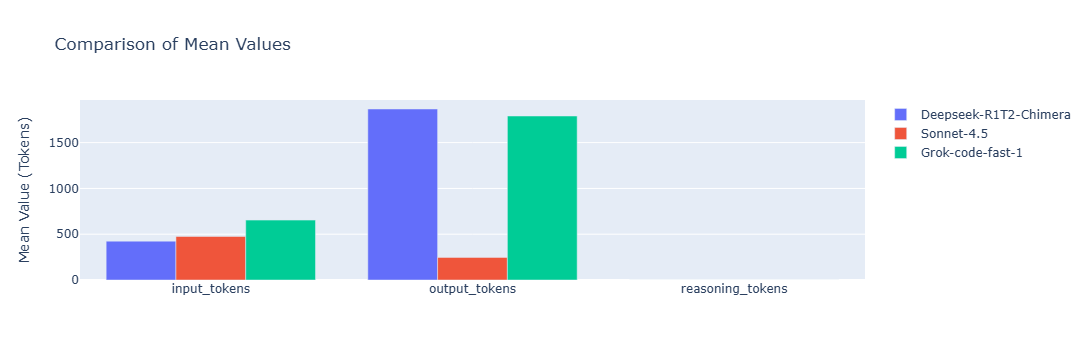

In [85]:
mean1 = deep_df[["input_tokens", "output_tokens", "reasoning_tokens"]].mean()
mean2 = sonnet_df[["input_tokens", "output_tokens", "reasoning_tokens"]].mean()
mean3 = grok_df[["input_tokens", "output_tokens", "reasoning_tokens"]].mean()
columns = mean1.index.tolist()
fig = go.Figure(data=[
    go.Bar(name='Deepseek-R1T2-Chimera', x=columns, y=mean1.values),
    go.Bar(name='Sonnet-4.5', x=columns, y=mean2.values),
    go.Bar(name='Grok-code-fast-1', x=columns, y=mean3.values)
])
fig.update_layout(
    barmode='group',
    title="Comparison of Mean Values",
    yaxis_title="Mean Value (Tokens)"
)
fig.show()

In [69]:
columns = ['problem','iteration','compile_error','simulation_mismatches','total_matches']
simlogs_deep = pd.read_csv(r'C:\Users\durgamaniryudh\Desktop\Learn\llm_eval\dataset_spec-to-rtl_deepseek\logs_test\compile_simulation_summary.csv', names=columns, header=0)
simlogs_sonnet = pd.read_csv(r'C:\Users\durgamaniryudh\Desktop\Learn\llm_eval\dataset_spec-to-rtl_sonnet-4.5\logs_test\compile_simulation_summary.csv', names=columns, header=0)
simlogs_grok = pd.read_csv(r'C:\Users\durgamaniryudh\Desktop\Learn\llm_eval\dataset_spec-to-rtl_grok-code-fast\logs_test\compile_simulation_summary.csv', names=columns, header=0)

dfs = [simlogs_deep, simlogs_grok, simlogs_sonnet]
run_names = ['Deepseek-R1T2-Chimera', 'Grok-code-fast-1', 'Sonnet-4.5']

In [13]:
# Collect stats for all runs
compile_error_data = []
mismatch_pct_data = []
summary= []
for run_name, df in zip(run_names, dfs):
    
    # Compile error stats
    total_rows = len(df)
    compile_errors = df['compile_error'].fillna(1).astype(int).sum()
    compile_error_rate = compile_errors / total_rows if total_rows else 0
    compile_error_pct = compile_error_rate * 100
    
    # Mismatch stats (ignore rows with compile_error==1)
    sim_ok = df[df['compile_error'] == 0]
    sim_ok = sim_ok.dropna(subset=['simulation_mismatches', 'total_matches'])
    sim_ok['simulation_mismatches'] = sim_ok['simulation_mismatches'].astype(float)
    sim_ok['total_matches'] = sim_ok['total_matches'].astype(float)
    total_mismatches = sim_ok['simulation_mismatches'].sum()
    total_matches = sim_ok['total_matches'].sum()
    mismatch_pct = (total_mismatches / total_matches * 100) if total_matches else 0
    
    summary.append({
        'run': run_name,
        'total_cases': total_rows,
        'compile_errors': compile_errors,
        'compile_error_%': round(compile_error_pct, 2),
        'total_mismatches': int(total_mismatches),
        'total_matches': int(total_matches),
        'mismatch_%': round(mismatch_pct, 2)
    })
    
summary_df =pd.DataFrame(summary)


In [14]:
summary_df


,run,total_cases,compile_errors,compile_error_%,total_mismatches,total_matches,mismatch_%
0,Deepseek,780,78,10.00,64463,1130964,5.70
1,Grok-code-fast,780,95,12.18,228706,960421,23.81
2,Sonnet-4.5,780,71,9.10,186586,1168325,15.97


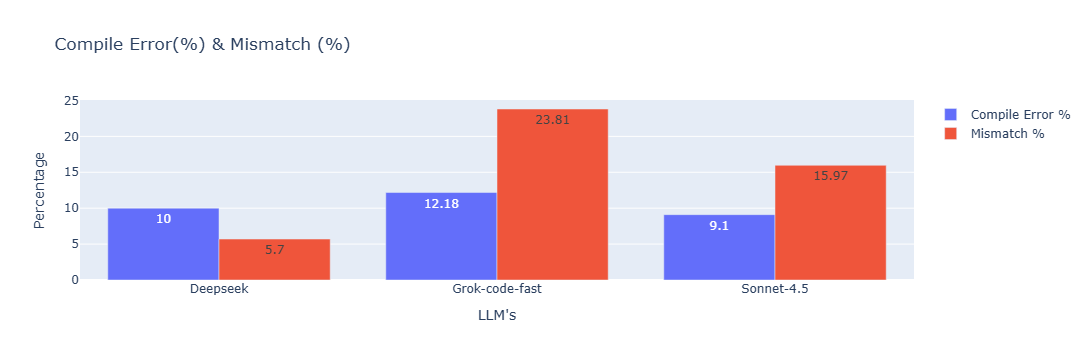

In [86]:
fig = go.Figure(data=[
    go.Bar(name='Compile Error %', x=summary_df['run'], y=summary_df['compile_error_%'], text=summary_df['compile_error_%'], textposition='auto'),
    go.Bar(name='Mismatch %', x=summary_df['run'], y=summary_df['mismatch_%'], text=summary_df['mismatch_%'], textposition='auto')
])
fig.update_layout(
    barmode='group',
    title="Compile Error(%) & Mismatch (%)",
    xaxis_title="LLM's",
    yaxis_title="Percentage"
)
fig.show()

In [90]:
def calculate_pass_at_k(df, k):
    """
    Calculates pass@k for compile and simulation for each problem.
    Returns simulation pass@k (fraction of problems with at least one passing attempt in top k).
    """
    # Group by problem, take top k iterations for each
    def is_pass(group):
        top_k = group.nsmallest(k, 'iteration')
        # Compile pass: at least one attempt with compile_error == 0
        compile_pass = (top_k['compile_error'] == 0).any()
        # Simulation pass: at least one attempt with compile_error == 0 and simulation_mismatches == 0
        sim_pass = ((top_k['compile_error'] == 0) & (top_k['simulation_mismatches'] == 0)).any()
        return pd.Series([compile_pass, sim_pass], index=['compile_pass', 'sim_pass'])

    pass_results = df.groupby('problem').apply(is_pass, include_groups=False)
    compile_pass_at_k = pass_results['compile_pass'].mean()
    sim_pass_at_k = pass_results['sim_pass'].mean()
    return compile_pass_at_k, sim_pass_at_k

compile_pass_1 = []
sim_pass_1 = []
compile_pass_5 = []
sim_pass_5 = []
compile_pass_10 = []
sim_pass_10 = []
for run_name, run_df in zip(run_names, dfs):
    compile_pass_at_1, sim_pass_at_1= calculate_pass_at_k(run_df, 1)
    compile_pass_at_5, sim_pass_at_5= calculate_pass_at_k(run_df, 5)
    compile_pass_at_10, sim_pass_at_10 = calculate_pass_at_k(run_df, 10)
    compile_pass_1.append(compile_pass_at_1)
    sim_pass_1.append(sim_pass_at_1)
    compile_pass_5.append(compile_pass_at_5)
    sim_pass_5.append(sim_pass_at_5)
    compile_pass_10.append(compile_pass_at_10)
    sim_pass_10.append(sim_pass_at_10)    
    print(f"{run_name}: Compile: pass@1 = {compile_pass_at_1:.3f}, pass@5 = {compile_pass_at_5:.3f}, pass@10 = {compile_pass_at_10:.3f}")
    print(f"{run_name}: Simulation: pass@1 = {sim_pass_at_1:.3f}, pass@5 = {sim_pass_at_5:.3f}, pass@10 = {sim_pass_at_10:.3f}")

Deepseek-R1T2-Chimera: Compile: pass@1 = 0.897, pass@5 = 0.987, pass@10 = 0.987
Deepseek-R1T2-Chimera: Simulation: pass@1 = 0.731, pass@5 = 0.885, pass@10 = 0.910
Grok-code-fast-1: Compile: pass@1 = 0.872, pass@5 = 0.987, pass@10 = 0.987
Grok-code-fast-1: Simulation: pass@1 = 0.667, pass@5 = 0.859, pass@10 = 0.910
Sonnet-4.5: Compile: pass@1 = 0.936, pass@5 = 0.936, pass@10 = 0.936
Sonnet-4.5: Simulation: pass@1 = 0.731, pass@5 = 0.782, pass@10 = 0.795


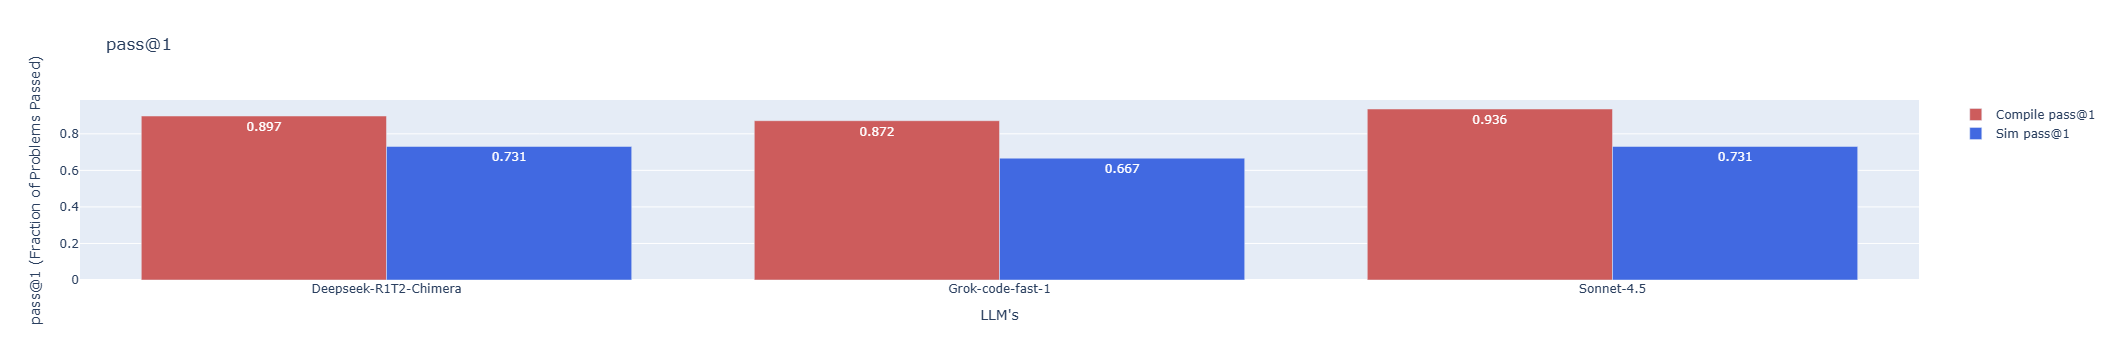

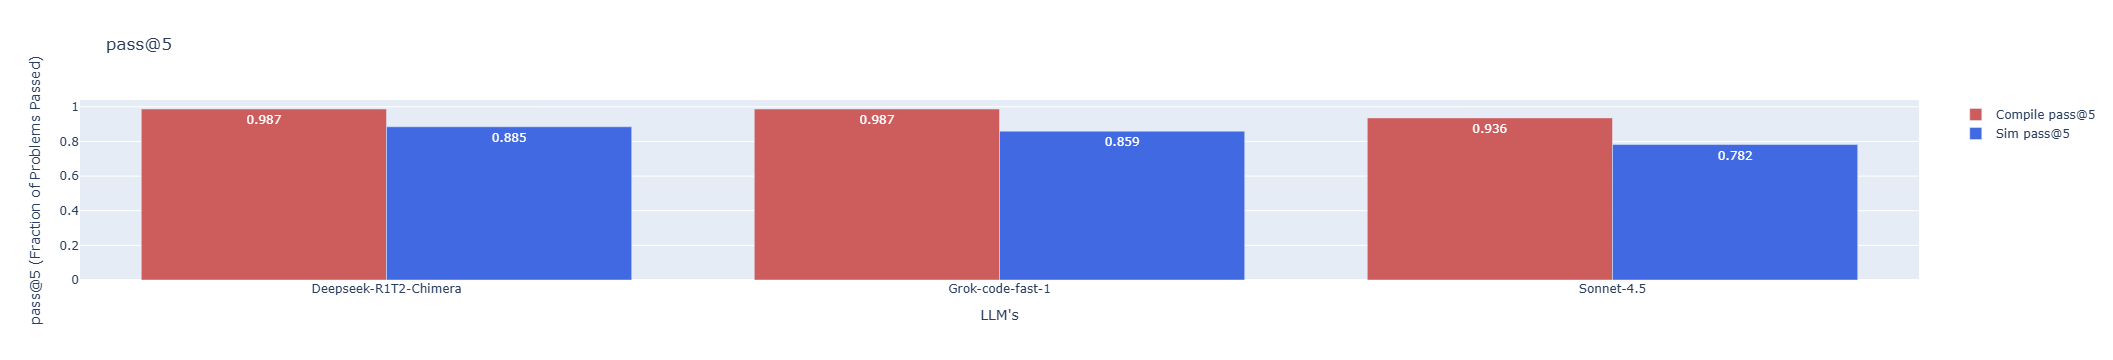

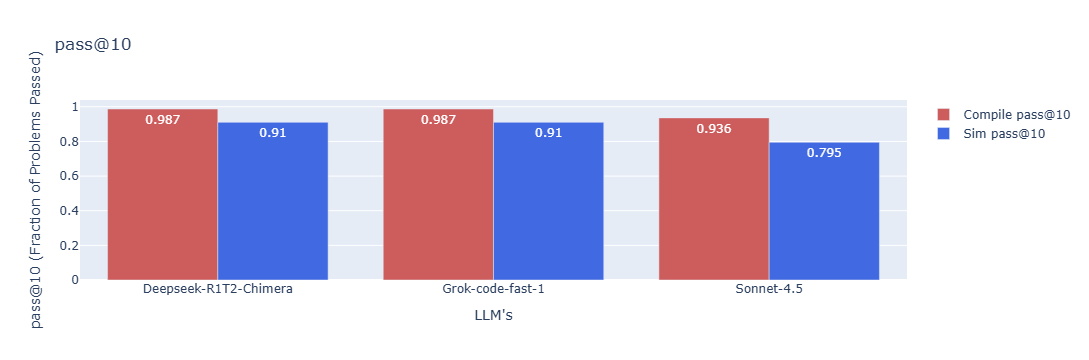

In [92]:
fig1 = go.Figure(data=[
    go.Bar(name='Compile pass@1', x=run_names, y=compile_pass_1, marker_color='indianred', text=np.round(compile_pass_1, 3), textposition='auto'),
    go.Bar(name='Sim pass@1', x=run_names, y=sim_pass_1, marker_color='royalblue', text=np.round(sim_pass_1, 3), textposition='auto')
])
fig1.update_layout(
    barmode='group',
    title='pass@1',
    yaxis_title='pass@1 (Fraction of Problems Passed)',
    xaxis_title="LLM's"
)
fig1.show()

fig2 = go.Figure(data=[
    go.Bar(name='Compile pass@5', x=run_names, y=compile_pass_5, marker_color='indianred', text=np.round(compile_pass_5, 3), textposition='auto'),
    go.Bar(name='Sim pass@5', x=run_names, y=sim_pass_5, marker_color='royalblue', text=np.round(sim_pass_5, 3), textposition='auto')
])
fig2.update_layout(
    barmode='group',
    title='pass@5',
    yaxis_title='pass@5 (Fraction of Problems Passed)',
    xaxis_title="LLM's"
)
fig2.show()

fig3 = go.Figure(data=[
    go.Bar(name='Compile pass@10', x=run_names, y=compile_pass_10, marker_color='indianred', text=np.round(compile_pass_10, 3), textposition='auto'),
    go.Bar(name='Sim pass@10', x=run_names, y=sim_pass_10, marker_color='royalblue', text=np.round(sim_pass_10, 3), textposition='auto')
])
fig3.update_layout(
    barmode='group',
    title='pass@10',
    yaxis_title='pass@10 (Fraction of Problems Passed)',
    xaxis_title="LLM's"
)
fig3.show()

# VerifyVerilog Dataset Analysis :

In [17]:
deepseek_metrics_log_path = r'C:\Users\durgamaniryudh\Desktop\Learn\llm_eval\dataset_verifyverilog_deepseek\metrics_log.csv'
minmax_metrics_log_path = r'C:\Users\durgamaniryudh\Desktop\Learn\llm_eval\dataset_verifyverilog_minmax\metrics_log.csv'
polaris_alpha_log_path = r'C:\Users\durgamaniryudh\Desktop\Learn\llm_eval\dataset_verifyverilog_polaris-alpha\metrics_log.csv'

def load_metrics(file_path):
    df = pd.read_csv(file_path)
    df.drop_duplicates(subset =['task_id','source'],inplace=True)
    return df
#deepseek_metrics = load_metrics(deepseek_metrics_log_path)

In [18]:
df_deepseek = load_metrics(deepseek_metrics_log_path)
df_minmax = load_metrics(minmax_metrics_log_path)
df_polaris_alpha = load_metrics(polaris_alpha_log_path)

In [19]:
print(df_deepseek.shape,df_minmax.shape,df_polaris_alpha.shape)


(1047, 11) (1067, 11) (1067, 11)


In [30]:
desc_deepseek = df_deepseek.describe()
desc_minmax = df_minmax.describe()
desc_polaris_alpha = df_polaris_alpha.describe()

print(f'Total input tokens for deepseek: {desc_deepseek['input_tokens']['mean'] * desc_deepseek['input_tokens']['count']}')
print(f'Total input tokens for minmax: {desc_minmax['input_tokens']['mean'] * desc_minmax['input_tokens']['count']}')
print(f'Total input tokens for polaris-alpha: {desc_polaris_alpha['input_tokens']['mean'] * desc_polaris_alpha['input_tokens']['count']}')
print('\n')
print(f'Total output tokens for deepseek: {desc_deepseek['output_tokens']['mean'] * desc_deepseek['output_tokens']['count']}')
print(f'Total output tokens for minmax: {desc_minmax['output_tokens']['mean'] * desc_minmax['output_tokens']['count']}')
print(f'Total output tokens for polaris-alpha: {desc_polaris_alpha['output_tokens']['mean'] * desc_polaris_alpha['output_tokens']['count']}')
print('\n')
print(f'Total reasoning tokens for deepseek: {desc_deepseek['reasoning_tokens']['mean'] * desc_deepseek['reasoning_tokens']['count']}')
print(f'Total reasoning tokens for minmax: {desc_minmax['reasoning_tokens']['mean'] * desc_minmax['reasoning_tokens']['count']}')
print(f'Total reasoning tokens for polaris-alpha: {desc_polaris_alpha['reasoning_tokens']['mean'] * desc_polaris_alpha['reasoning_tokens']['count']}')
#df_deepseek.select_dtypes(include='number').sum()

Total input tokens for deepseek: 563714.0
Total input tokens for minmax: 607029.0
Total input tokens for polaris-alpha: 573390.0


Total output tokens for deepseek: 7195915.0
Total output tokens for minmax: 11424777.0
Total output tokens for polaris-alpha: 1659126.0


Total reasoning tokens for deepseek: 0.0
Total reasoning tokens for minmax: 9877814.0
Total reasoning tokens for polaris-alpha: 0.0
